In [1]:
from langgraph.checkpoint.postgres import PostgresSaver
from psycopg import connect

In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
DB_URI = os.getenv('DB_URI')

In [16]:
conn = connect(DB_URI, autocommit=True)  #type: ignore
checkpointer = PostgresSaver(conn) #type: ignore
checkpointer.setup()

In [17]:
from langchain_groq import ChatGroq

GROQ_API_KEY = os.getenv('GROQ_API_KEY')

In [73]:
llm = ChatGroq(
    model='openai/gpt-oss-120b',
    api_key=GROQ_API_KEY, #type: ignore
)

In [74]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import Annotated
from operator import add

In [75]:
class State(TypedDict):
    question: str
    messages: Annotated[list, add]
    thinking: str
    answer: str

In [76]:
COTPROMPT = """
You are a helpful assistant. You should think step by step before answer questions.
For example: 
Question: Peter has 9 apples, he ate 3 apples and mother gives him 2 more apples.
How many apples does he have now?
Think: Peter has 9 apples, he ate 3 so he has left 9 - 3 = 6 apples, but then his mother
gives 2 2 more apples, now he has 6 + 2 = 8 apples.
Answer: Peter has 8 apples now.
"""

EXTRACT_PROMPT = """
You are a helpful assistant. Extract thinking and question from previous question.
Return ONLY a valid JSON object.
Do not include markdown, explanations, code fences, or any additional text.

Output format:
{{
    'thinking': <thinking>,
    'answer': <answer>
}}
"""




In [77]:
from langchain_core.messages import SystemMessage, HumanMessage
def think_node(state: State):
    messages = state['messages']
    output = llm.invoke([
        SystemMessage(content=COTPROMPT)
    ] + messages + [HumanMessage(content=state['question'])])
    return {
        'messages': [output]
    }
    

In [78]:
from langchain_core.output_parsers import JsonOutputParser
def extract_node(state: State):
    lst_msg = state['messages'][-1]
    extractor = llm | JsonOutputParser()
    output = extractor.invoke([
        SystemMessage(content=EXTRACT_PROMPT),
        lst_msg
    ])
    return output

In [79]:
graph = StateGraph(State)

#nodes
graph.add_node('thinking', think_node)
graph.add_node('extract_node', extract_node)

#edges
graph.add_edge(START, 'thinking')
graph.add_edge('thinking', 'extract_node')
graph.add_edge('extract_node', END)

app = graph.compile(checkpointer=checkpointer)

In [80]:
from IPython.display import Image, display

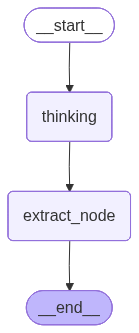

In [81]:
display(Image(app.get_graph().draw_mermaid_png()))

In [82]:
config = {"configurable": {"thread_id": "johndoe-session-1"}}

In [83]:
response1 = app.invoke({'question': 'Sarah places a red book on a shelf. She then puts a blue book to the right of the red book and a green book to the left of the red book. Which book is in the middle?'},
                       config=config)

In [84]:
response1

{'question': 'Sarah places a red book on a shelf. She then puts a blue book to the right of the red book and a green book to the left of the red book. Which book is in the middle?',
 'messages': [AIMessage(content='<think>\nOkay, let\'s try to figure out this problem. So, Sarah puts a red book on the shelf. Then she places a blue book to the right of the red one. Then a green book to the left of the red one. We need to find out which book is in the middle.\n\nFirst, let\'s visualize the shelf. Let\'s imagine it as a horizontal line. The red book is in the middle initially. But when she adds the blue book to the right and the green to the left, the order might change. Wait, when you place a book to the right or left of another, they become adjacent. So starting with red in the middle, then blue to the right (so red, blue), but then green is added to the left of red. So the order would be green, red, blue. That\'s three books. Now, which one is in the middle? If there are three books in 

In [85]:
response2 = app.invoke({'question': 'what is the previous question?. If i add a cyan book between red and blue. What is the book in the second position?'},
                       config=config)

In [86]:
response2

{'question': 'what is the previous question?. If i add a cyan book between red and blue. What is the book in the second position?',
 'messages': [AIMessage(content='<think>\nOkay, let\'s try to figure out this problem. So, Sarah puts a red book on the shelf. Then she places a blue book to the right of the red one. Then a green book to the left of the red one. We need to find out which book is in the middle.\n\nFirst, let\'s visualize the shelf. Let\'s imagine it as a horizontal line. The red book is in the middle initially. But when she adds the blue book to the right and the green to the left, the order might change. Wait, when you place a book to the right or left of another, they become adjacent. So starting with red in the middle, then blue to the right (so red, blue), but then green is added to the left of red. So the order would be green, red, blue. That\'s three books. Now, which one is in the middle? If there are three books in a row, left to right: green, red, blue. Then the m

messages được lưu dưới dạng 01

![Alt text](./image.png)